In [2]:
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END

In [3]:
load_dotenv()

True

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [ ]:
class StudentState(TypedDict):
    name: str
    age: int
    marks: int
    eligible: bool
    message: str

In [6]:
def validate_student(state: StudentState):
    if state["age"] < 18:
        return {
            "eligible":False
        }

    if state["marks"] >=  60:
        return {
            "eligible" : True
        } 

    return {
        "eligible":False
    }

In [7]:
def route_student(state: StudentState):
    if state['eligible']:
        return "admission"

    return "rejection"

In [8]:
def admission(state: StudentState):
    return {
        "message": f"{state['name']} has been admitted"
    }

In [9]:
def rejection(state: StudentState):
    return {
        "message": f"{state['name']} has been rejected"
    }

In [10]:
builder = StateGraph(StudentState)

In [11]:
builder.add_node("validate_student", validate_student)
builder.add_node("admission", admission)
builder.add_node("rejection", rejection)

In [12]:
builder.add_edge(START, "validate_student")

In [13]:
builder.add_conditional_edges(
    "validate_student", route_student,
    {
        "admission" : "admission",
        "rejection" : "rejection"
    }
)

In [14]:
builder.add_edge(
    "admission",
    END
)

builder.add_edge(
    "rejection",
    END
)

In [15]:
graph = builder.compile()

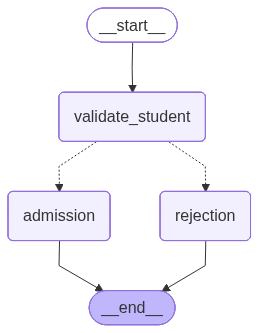

In [16]:
graph

In [18]:
result = graph.invoke(
    {
        "name": "Mohit",
        "age": 20,
        "marks": 2
    }
)

print(result)

{'name': 'Mohit', 'age': 20, 'marks': 2, 'eligible': False, 'message': 'Mohit has been rejected'}
